# SNP data and *mapper* / SNP 데이터와 *mapper*

In [308]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'
from plotly.subplots import make_subplots
from data import load_data

df = load_data()
fd = df.transpose().iloc[3:]

base_freq = np.zeros((df.shape[1]-3, 4))
for num, (name, col) in enumerate(df.iloc[:, 3:].items()):
    base_freq[num, 0] = col.str.count('A').sum()
    base_freq[num, 1] = col.str.count('C').sum()
    base_freq[num, 2] = col.str.count('G').sum()
    base_freq[num, 3] = col.str.count('T').sum()
base_freq_rel = base_freq / np.sum(base_freq, axis=1, keepdims=True)

mask_AC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 1], axis=1)
mask_CA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 0], axis=1)
mask_AG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 2], axis=1)
mask_GA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 0], axis=1)
mask_CT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 3], axis=1)
mask_TC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 1], axis=1)
mask_GT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 3], axis=1)
mask_TG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 2], axis=1)

mask_AC_CA = mask_AC | mask_CA
mask_AG_GA = mask_AG | mask_GA
mask_CT_TC = mask_CT | mask_TC
mask_GT_TG = mask_GT | mask_TG

## 샘플들(사람들)간의 거리를 측정한다

In [234]:
import itertools

dist_d = np.zeros((df.shape[0], df.shape[0]))
for i in range(df.shape[0]):
    dist_d[i] = (df.iloc[i, 3:] != df.iloc[:, 3:]).sum(axis=1)

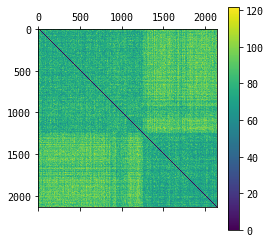

In [235]:
plt.colorbar(plt.matshow(dist_d))

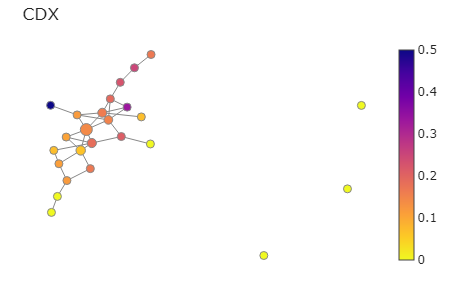

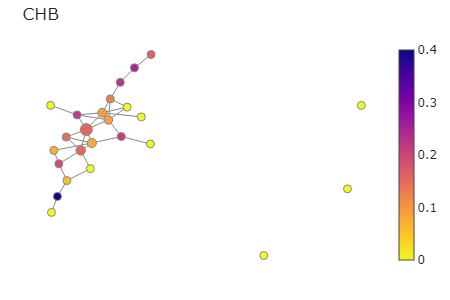

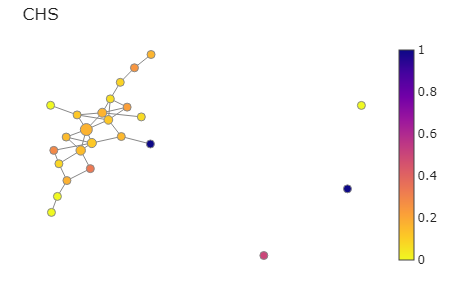

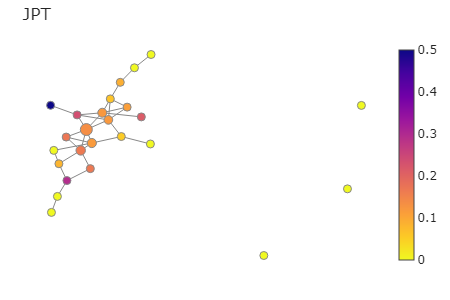

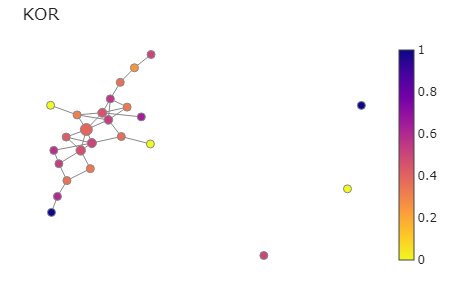

In [325]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union
# from umap import UMAP


# umap = UMAP(random_state=42)

mask = df['Geographic region'] == 'NEA'

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=6, overlap_frac=0.08),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)

for num, pop in enumerate(df.loc[mask, 'POP-ID'].unique()):
    fig = plot_static_mapper_graph(
        pipe, 
        dist_d[mask][:, mask],
        color_data=(df.loc[mask,'POP-ID']==pop),
        plotly_params={
            'node_trace': {'marker_colorscale': 'plasma_r'},
            'layout': {'title': pop}
        }
    )
    fig.show(renderer='png', width=450, height=300)
    # fig.show()
    fig.close()

## 특성들(rs####)간의 거리를 측정한다

In [5]:
import itertools

dist_f = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in itertools.combinations(range(fd.shape[0]), 2):
    dist_f[i, j] = (fd.iloc[i] != fd.iloc[j]).sum()
    dist_f[j, i] = dist_f[i, j]


각 특성은 발견되는 염기에 따라 크게 네 가지(A&C, A&G, C&T, G&T)로 구분된다.

이들을 한꺼번에 분석하면 intra 관계보다 inter관계가 부각되어 재미가 없습니다. 

그러므로 당신은 표본으로서 C&T만 관찰하기를 바랄 것이다.

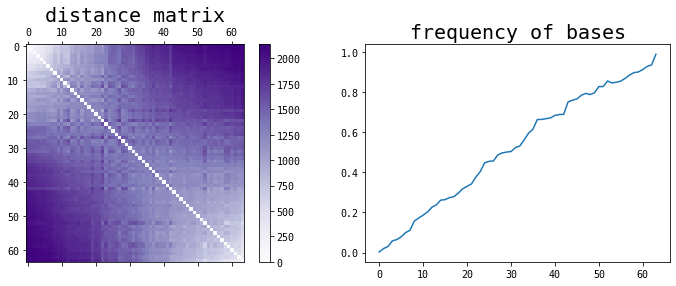

In [133]:
mask = mask_CT_TC
# mask = (base_freq_rel[:, 1] > 0.3) & (base_freq_rel[:, 3] > 0.3)

sorter = np.argsort(base_freq[mask, 3])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# plt.gca().matshow(dist_mat[mask][:, mask][sorter][:, sorter])
plt.colorbar(
    plt.gca().matshow(dist_f[mask][:, mask][sorter][:, sorter], cmap='Purples')
)
plt.title('distance matrix', fontsize=20)

plt.subplot(1, 2, 2)
plt.gca().plot(base_freq_rel[mask_CT_TC, 3][sorter])
plt.title('frequency of bases', fontsize=20)

plt.show(); plt.close()

여러 시각화 방법을 동원한다 첫째로 차원 감소를 탐구합니다.

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\umap\umap_.py:1780: UserWarning:

using precomputed metric; inverse_transform will be unavailable



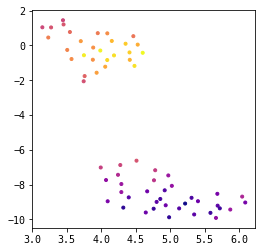

In [96]:
from umap import UMAP
# from sklearn.cluster import KMeans

umap = UMAP(
    random_state=42,
    metric='precomputed'
)
mask = mask_CT_TC
# mask = (base_freq_rel[:, 1] > 0.1) & (base_freq_rel[:, 3] > 0.1)
reduced = umap.fit_transform(dist_f[mask][:, mask])
# k_means = KMeans(n_clusters=4)
# k_means.fit(reduced)

plt.figure(figsize=(4, 4))
plt.scatter(
    *reduced.T, 
    s=9.,
    c=base_freq[mask, 3],
    cmap='plasma_r'
)
plt.show(); plt.close()

그러나 *mapper*가 보여주는 풍경은 사뭇 다릅니다.

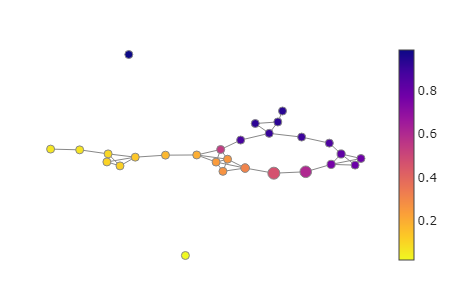

In [108]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union

mask = mask_CT_TC

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=7, overlap_frac=0.28),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 3],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show(renderer='png', width=450, height=300)
fig.close()

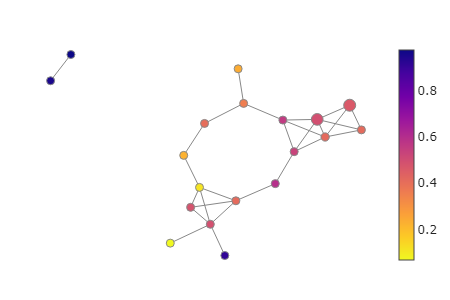

In [182]:
mask = mask_AG_GA

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=6, overlap_frac=0.3),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 0],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show(renderer='png', width=450, height=300)
fig.close()

In [226]:
mask = mask_AG_GA

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=6, overlap_frac=0.27),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    dist_f[mask][:, mask],
    color_data=base_freq_rel[mask, 0],
    plotly_params={'node_trace': {'marker_colorscale': 'plasma_r'}}
)
fig.show()
fig.close()